<a href="https://colab.research.google.com/github/nknak-crypto/Machine-Learning-Supervisado/blob/main/TP_1_Grupo_9.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Trabajo Grupal Clase 1: Análisis de Ventas en BigMart - Grupo 9

BigMart es una cadena minorista con presencia en múltiples ciudades que ha registrado
durante años información detallada de ventas, características de productos y tiendas. La
empresa enfrenta desafíos para optimizar su inventario, entender mejor los factores que
influyen en sus ventas y diseñar estrategias de expansión más efectivas.

1. Análisis del portafolio por categoría de producto

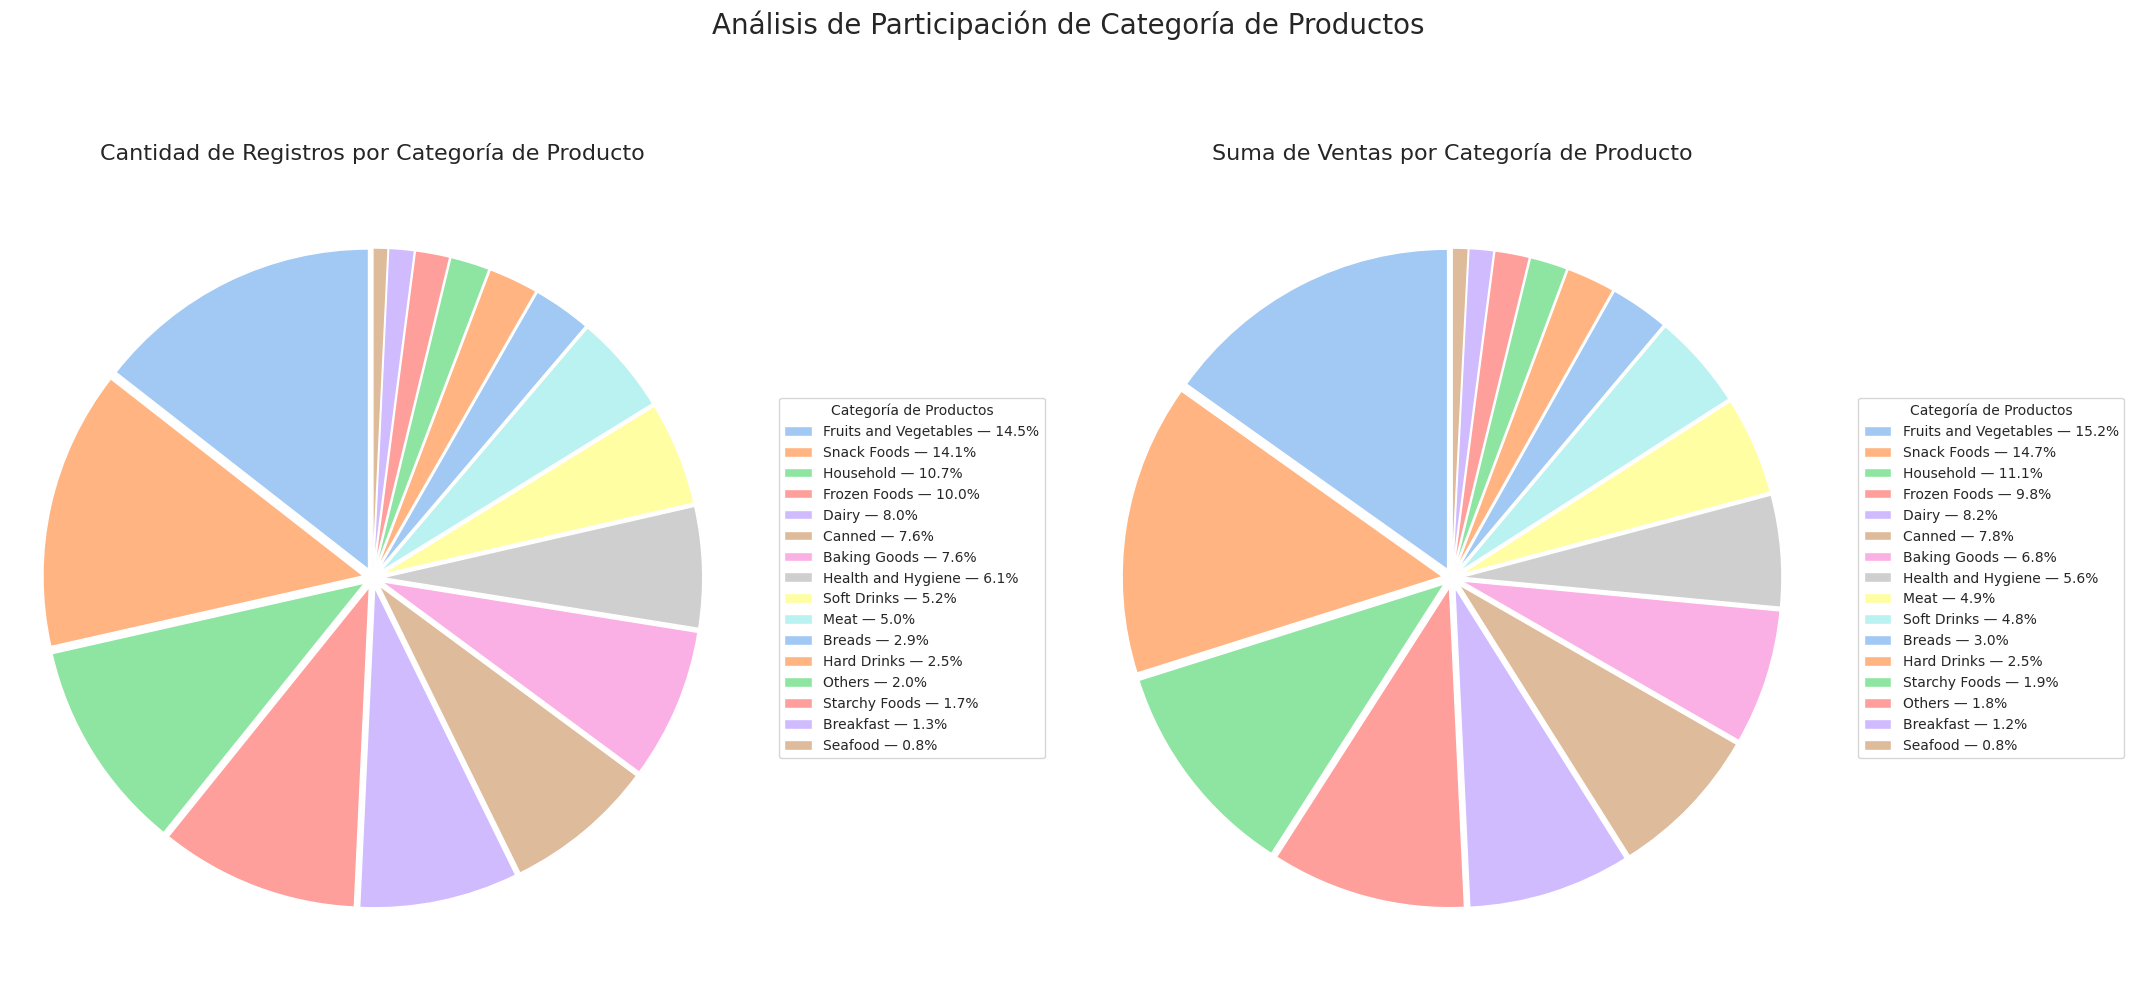

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset
df = pd.read_csv('/content/TP bigmart_data (1).csv')

# Ordenar de mayor a menor
item_type_counts = df['Item_Type'].value_counts().sort_values(ascending=False)
item_type_sales = df.groupby('Item_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

# Estilo y colores
sns.set_style("white")
num_item_types = len(item_type_counts.index)
colors = sns.color_palette("pastel", n_colors=num_item_types)
explode_list = [0.03] * num_item_types

# Figura
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
fig.suptitle('Análisis de Participación de Categoría de Productos', fontsize=20, y=1.02)

# --- Torta 1: Cantidad de productos ---
wedges1, _ = axes[0].pie(
    item_type_counts,
    startangle=90,
    colors=colors,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
    explode=explode_list,
    radius=1,
    autopct=None,
    labels=None
)
axes[0].set_title('Cantidad de Registros por Categoría de Producto', fontsize=16)
axes[0].axis('equal')

total1 = item_type_counts.sum()
legend_labels1 = [f'{name} — {(count/total1*100):.1f}%' for name, count in item_type_counts.items()]
axes[0].legend(wedges1, legend_labels1, title="Categoría de Productos",
               loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=10)

# --- Torta 2: Ventas totales ---
wedges2, _ = axes[1].pie(
    item_type_sales,
    startangle=90,
    colors=colors,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
    explode=explode_list,
    radius=1,
    autopct=None,
    labels=None
)
axes[1].set_title('Suma de Ventas por Categoría de Producto', fontsize=16)
axes[1].axis('equal')

total2 = item_type_sales.sum()
legend_labels2 = [f'{name} — {(sales/total2*100):.1f}%' for name, sales in item_type_sales.items()]
axes[1].legend(wedges2, legend_labels2, title="Categoría de Productos",
               loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=10)

plt.tight_layout(pad=3)
plt.show()

2. Análisis por tipo de tienda y ubicación geográfica (tier)

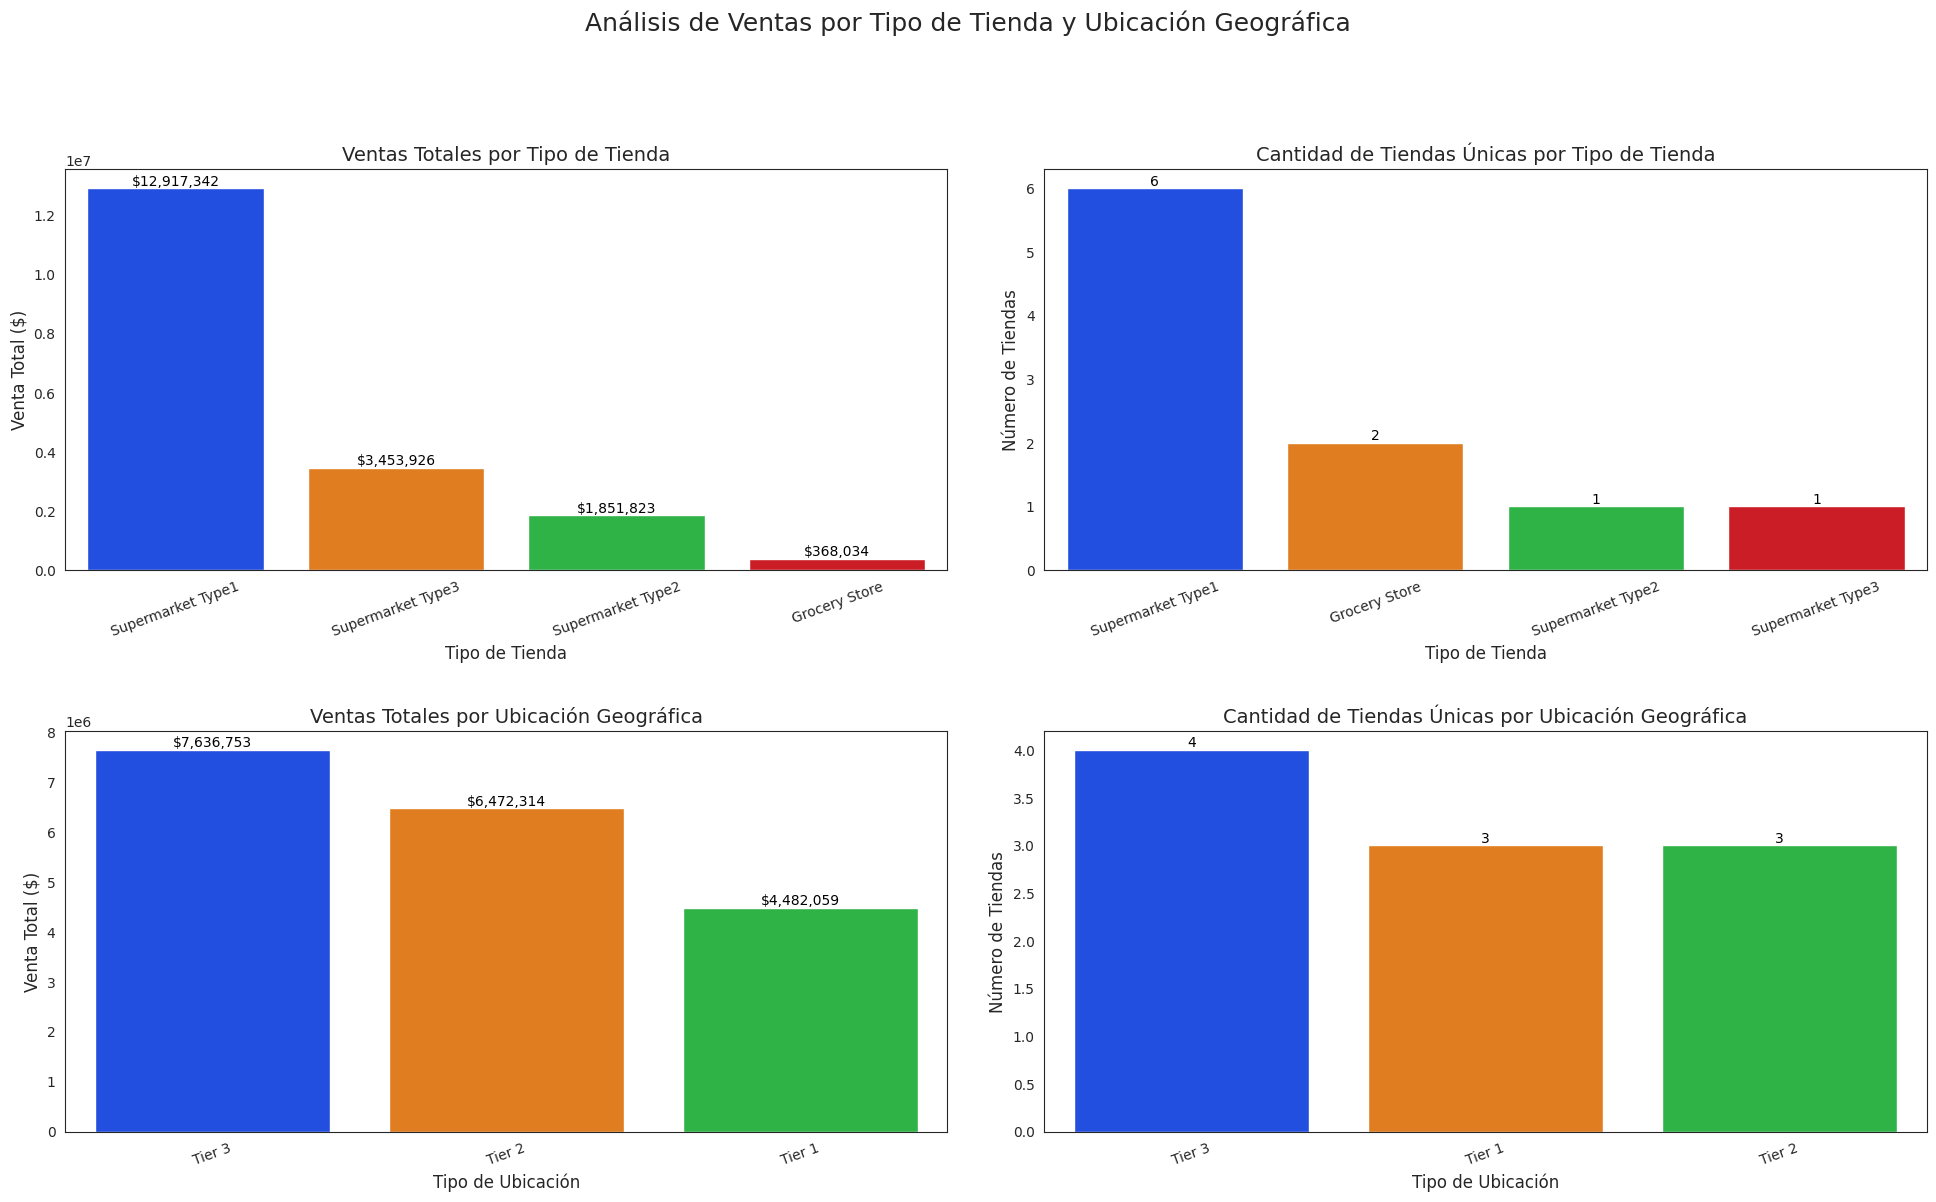


--- Recomendaciones Comerciales ---
RECOMENDACIÓN 1 — Fortalecer y expandir estrategias exitosas del formato "Supermarket Type1" que lidera con $12,917,342 en ventas totales.
RECOMENDACIÓN 2 — Analizar y replicar el modelo de "Supermarket Type3" que muestra la mayor eficiencia, con $3,453,926 en ventas promedio por tienda.
RECOMENDACIÓN 3 — Considerar la expansión en ubicaciones como "Tier 2". A pesar de tener menos tiendas (3), muestran una alta eficiencia con $2,157,438 de venta promedio por tienda, indicando un potencial de crecimiento significativo.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset (assuming df is already loaded from previous cells)
try:
    df = pd.read_csv('/content/TP bigmart_data.csv')
except FileNotFoundError:
    print("Error: 'TP bigmart_data.csv' not found. Please ensure the file is uploaded correctly.")
    exit()

# Set plotting style
sns.set_style("white") # Clean, white background

# --- Data Aggregations for Plots and Recommendations ---
# Ventas totales por Outlet_Type
total_sales_by_outlet_type = df.groupby('Outlet_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

# Cantidad de tiendas únicas por Outlet_Type
unique_outlets_by_outlet_type = df.groupby('Outlet_Type')['Outlet_Identifier'].nunique().sort_values(ascending=False)

# Ventas totales por Outlet_Location_Type
total_sales_by_location_type = df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

# Cantidad de tiendas únicas por Outlet_Location_Type
unique_outlets_by_location_type = df.groupby('Outlet_Location_Type')['Outlet_Identifier'].nunique().sort_values(ascending=False)

# Ventas promedio por tienda para cada Outlet_Type (needed for recommendations)
avg_sales_per_store_by_outlet_type = (total_sales_by_outlet_type / unique_outlets_by_outlet_type).fillna(0).sort_values(ascending=False)

# Ventas promedio por tienda para cada Outlet_Location_Type (needed for recommendations)
avg_sales_per_store_by_location_type = (total_sales_by_location_type / unique_outlets_by_location_type).fillna(0).sort_values(ascending=False)

# --- Create figure and subplots ---
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Análisis de Ventas por Tipo de Tienda y Ubicación Geográfica', fontsize=18, y=1.02)

# --- Plot 1 (Top-Left): Ventas totales por Outlet_Type ---
ax1 = axes[0, 0]
sns.barplot(x=total_sales_by_outlet_type.index, y=total_sales_by_outlet_type.values, palette='bright', ax=ax1, hue=total_sales_by_outlet_type.index, legend=False)
ax1.set_title('Ventas Totales por Tipo de Tienda', fontsize=14)
ax1.set_xlabel('Tipo de Tienda', fontsize=12)
ax1.set_ylabel('Venta Total ($)', fontsize=12)
ax1.tick_params(axis='x', rotation=20)
for p in ax1.patches:
    ax1.annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, color='black')

# --- Plot 2 (Top-Right): Cantidad de tiendas únicas por Outlet_Type ---
ax2 = axes[0, 1]
sns.barplot(x=unique_outlets_by_outlet_type.index, y=unique_outlets_by_outlet_type.values, palette='bright', ax=ax2, hue=unique_outlets_by_outlet_type.index, legend=False)
ax2.set_title('Cantidad de Tiendas Únicas por Tipo de Tienda', fontsize=14)
ax2.set_xlabel('Tipo de Tienda', fontsize=12)
ax2.set_ylabel('Número de Tiendas', fontsize=12)
ax2.tick_params(axis='x', rotation=20)
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, color='black')

# --- Plot 3 (Bottom-Left): Ventas totales por Outlet_Location_Type ---
ax3 = axes[1, 0]
sns.barplot(x=total_sales_by_location_type.index, y=total_sales_by_location_type.values, palette='bright', ax=ax3, hue=total_sales_by_location_type.index, legend=False)
ax3.set_title('Ventas Totales por Ubicación Geográfica', fontsize=14)
ax3.set_xlabel('Tipo de Ubicación', fontsize=12)
ax3.set_ylabel('Venta Total ($)', fontsize=12)
ax3.tick_params(axis='x', rotation=20)
for p in ax3.patches:
    ax3.annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, color='black')

# --- Plot 4 (Bottom-Right): Cantidad de tiendas únicas por Outlet_Location_Type ---
ax4 = axes[1, 1]
sns.barplot(x=unique_outlets_by_location_type.index, y=unique_outlets_by_location_type.values, palette='bright', ax=ax4, hue=unique_outlets_by_location_type.index, legend=False)
ax4.set_title('Cantidad de Tiendas Únicas por Ubicación Geográfica', fontsize=14)
ax4.set_xlabel('Tipo de Ubicación', fontsize=12)
ax4.set_ylabel('Número de Tiendas', fontsize=12)
ax4.tick_params(axis='x', rotation=20)
for p in ax4.patches:
    ax4.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, color='black')

plt.tight_layout(pad=3) # Adjust layout to prevent overlapping elements
plt.show()

# --- Commercial Recommendations ---
print('\n--- Recomendaciones Comerciales ---')

# Recommendation 1: Leverage the top-performing Outlet_Type by total sales
best_total_sales_outlet_type = total_sales_by_outlet_type.index[0]
best_total_sales_value = total_sales_by_outlet_type.values[0]
print(f'RECOMENDACIÓN 1 — Fortalecer y expandir estrategias exitosas del formato "{best_total_sales_outlet_type}" que lidera con ${best_total_sales_value:,.0f} en ventas totales.')

# Recommendation 2: Capitalize on efficiency of a specific Outlet_Type
most_efficient_outlet_type = avg_sales_per_store_by_outlet_type.index[0]
most_efficient_value = avg_sales_per_store_by_outlet_type.values[0]
print(f'RECOMENDACIÓN 2 — Analizar y replicar el modelo de "{most_efficient_outlet_type}" que muestra la mayor eficiencia, con ${most_efficient_value:,.0f} en ventas promedio por tienda.')

# Recommendation 3: Opportunity in a specific Outlet_Location_Type
# Find location with good average sales per store but not necessarily the most stores
# Assuming 'Tier 2' is identified as having high average sales per store but potentially fewer total stores than 'Tier 3'

# Re-calculate or get relevant variables for clarity in recommendation
tier2_avg_sales_per_store = avg_sales_per_store_by_location_type.get('Tier 2', 0)
tier2_num_outlets = unique_outlets_by_location_type.get('Tier 2', 0)

tier1_avg_sales_per_store = avg_sales_per_store_by_location_type.get('Tier 1', 0)
tier1_num_outlets = unique_outlets_by_location_type.get('Tier 1', 0)

tier3_avg_sales_per_store = avg_sales_per_store_by_location_type.get('Tier 3', 0)
tier3_num_outlets = unique_outlets_by_location_type.get('Tier 3', 0)

if tier2_avg_sales_per_store > tier1_avg_sales_per_store and tier2_num_outlets < tier3_num_outlets: # Tier 2 is efficient but has fewer stores than Tier 3 (top in total stores)
    print(f'RECOMENDACIÓN 3 — Considerar la expansión en ubicaciones como "Tier 2". A pesar de tener menos tiendas ({tier2_num_outlets}), muestran una alta eficiencia con ${tier2_avg_sales_per_store:,.0f} de venta promedio por tienda, indicando un potencial de crecimiento significativo.')
elif tier1_avg_sales_per_store > 0 and tier1_avg_sales_per_store < tier2_avg_sales_per_store: # Tier 1 is less efficient than Tier 2, but still present
    print(f'RECOMENDACIÓN 3 — Investigar oportunidades de mejora para ubicaciones en "Tier 1". Aunque tiene una presencia considerable ({tier1_num_outlets} tiendas), su eficiencia promedio por tienda es de ${tier1_avg_sales_per_store:,.0f}, inferior a otros tiers, sugiriendo optimización operativa.')
else:
    # Fallback or a more general recommendation if specific conditions aren't met
    lowest_avg_sales_per_store_location = avg_sales_per_store_by_location_type.idxmin()
    lowest_avg_sales_per_store_value = avg_sales_per_store_by_location_type.min()
    print(f'RECOMENDACIÓN 3 — Analizar los desafíos específicos en "{lowest_avg_sales_per_store_location}" que presenta la menor venta promedio por tienda (${lowest_avg_sales_per_store_value:,.0f}) para identificar barreras y oportunidades de mejora.')

3. Top 10 productos con mayores ventas totales

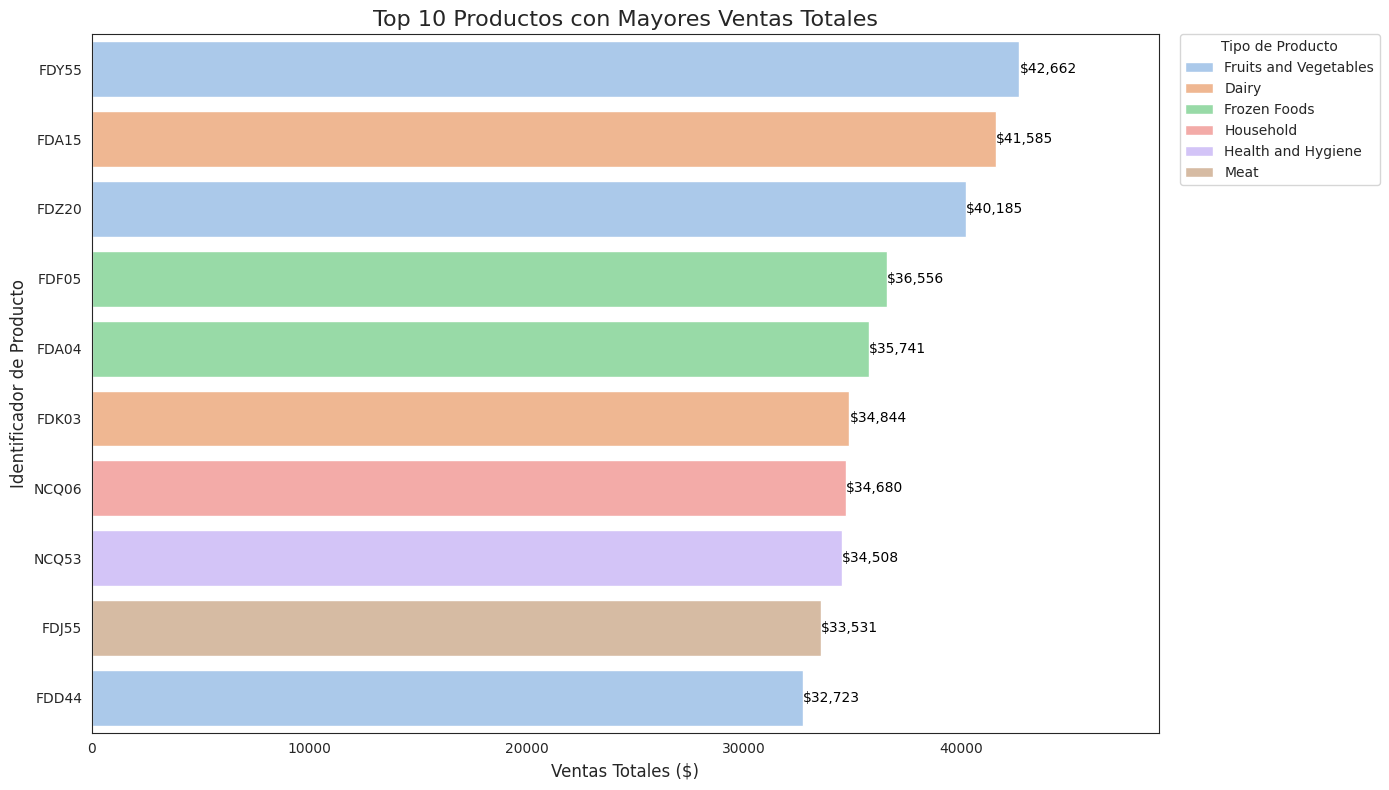

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' DataFrame is already loaded from previous cells
# Calculate total sales per Item_Identifier and get the Item_Type
top_10_products_sales = df.groupby(['Item_Identifier', 'Item_Type'])['Item_Outlet_Sales'].sum().reset_index()
top_10_products_sales = top_10_products_sales.sort_values(by='Item_Outlet_Sales', ascending=False).head(10)

# Set plotting style
sns.set_style("white") # Clean style, white background

# Create the horizontal bar chart
plt.figure(figsize=(14, 8))
# Use Item_Identifier for y-axis, Item_Outlet_Sales for x-axis, and Item_Type for hue
sns.barplot(x='Item_Outlet_Sales', y='Item_Identifier', hue='Item_Type', data=top_10_products_sales, palette='pastel', dodge=False)

plt.title('Top 10 Productos con Mayores Ventas Totales', fontsize=16)
plt.xlabel('Ventas Totales ($)', fontsize=12)
plt.ylabel('Identificador de Producto', fontsize=12)

# Add values at the end of each bar
# The y-position for text annotation should correspond to the row index of the dataframe used by barplot
for index, row in top_10_products_sales.reset_index().iterrows():
    plt.text(row['Item_Outlet_Sales'], index, f'${row['Item_Outlet_Sales']:,.0f}',
             color='black', ha="left", va="center", fontsize=10)

# Adjust x-axis limits to make space for labels
plt.xlim(0, top_10_products_sales['Item_Outlet_Sales'].max() * 1.15)

# Add legend, title, and adjust position
plt.legend(title='Tipo de Producto', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

4. Top 10 productos por categoría (Item_Type)

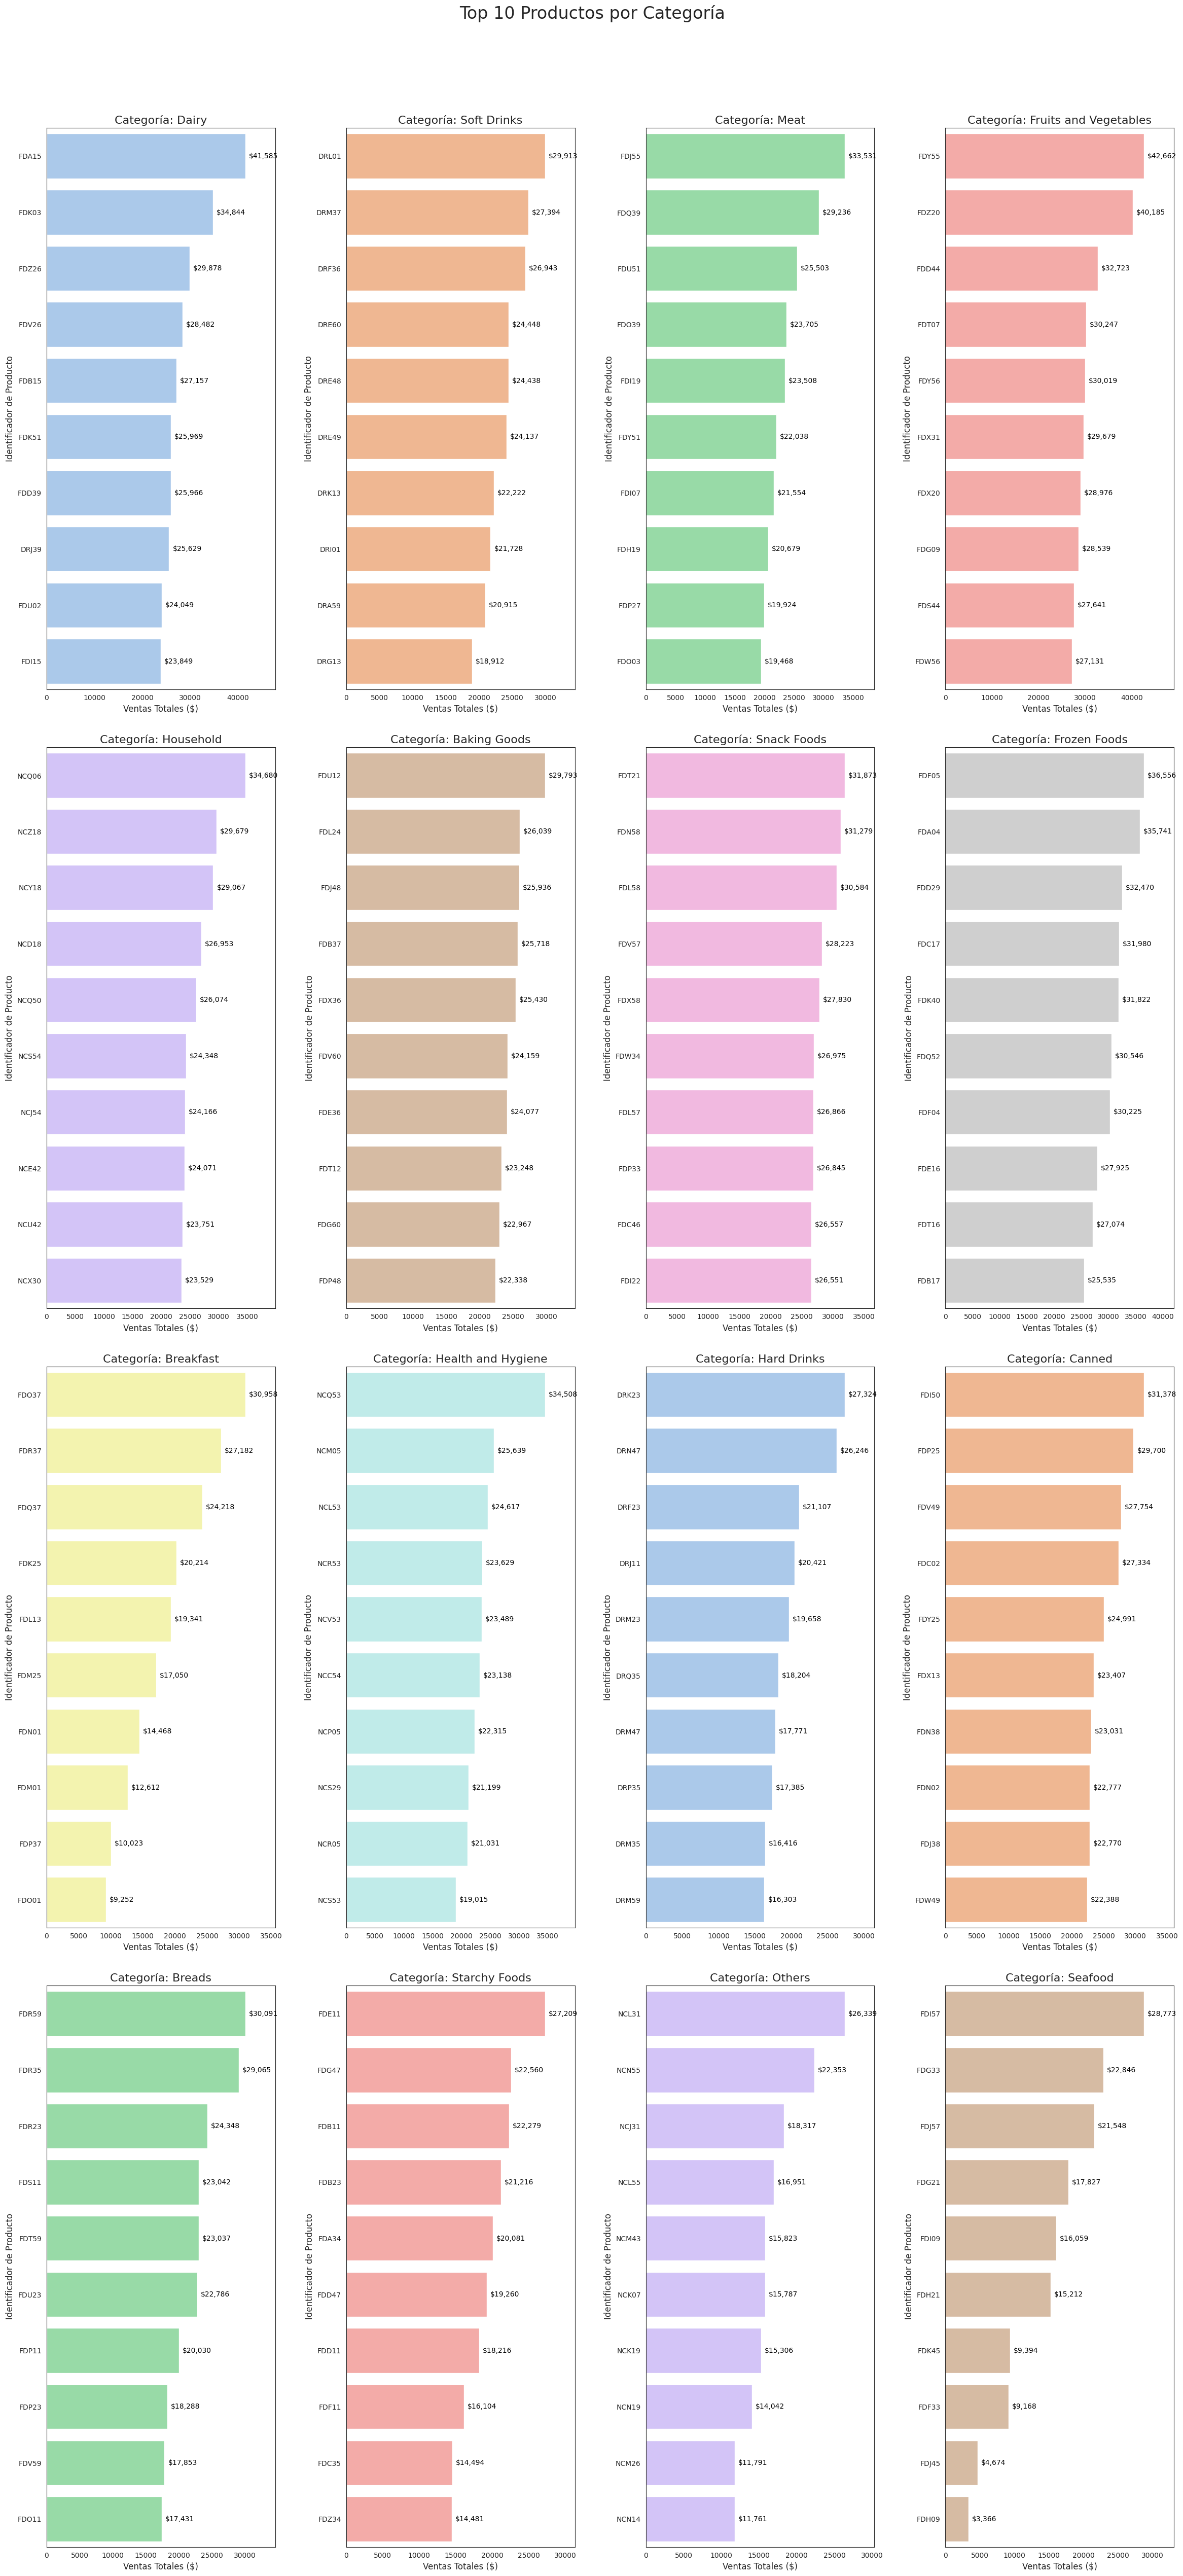

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Assuming 'df' DataFrame is already loaded from previous cells

# Get unique Item_Types
item_types = df['Item_Type'].unique()
num_item_types = len(item_types)

# Determine the number of rows needed for the subplot grid (4 columns)
num_cols = 4
num_rows = math.ceil(num_item_types / num_cols)

# Set plotting style
sns.set_style("white")

# Create a figure and a grid of subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(24, 50))
# Flatten the axes array for easier iteration
axes = axes.flatten()

fig.suptitle('Top 10 Productos por Categoría', fontsize=24, y=1.02) # General title

# Create a pastel color palette with enough colors for all categories
palette = sns.color_palette("pastel", n_colors=num_item_types)

# Iterate through each Item_Type and create a subplot
for i, item_type in enumerate(item_types):
    ax = axes[i]

    # Filter DataFrame for the current Item_Type
    df_item_type = df[df['Item_Type'] == item_type]

    # Calculate total sales per Item_Identifier for this Item_Type
    top_products = df_item_type.groupby('Item_Identifier')['Item_Outlet_Sales'].sum().reset_index()

    # Sort and get the top 10 (or fewer if less than 10 are available)
    top_products = top_products.sort_values(by='Item_Outlet_Sales', ascending=False).head(10)

    # Get a specific color for this Item_Type from the palette
    current_color = palette[i % len(palette)] # Use modulo to cycle if more item_types than palette colors

    # Create the horizontal bar chart
    # Use 'color' argument to apply a single color to all bars in the subplot
    sns.barplot(x='Item_Outlet_Sales', y='Item_Identifier', data=top_products, color=current_color, ax=ax, dodge=False)

    ax.set_title(f'Categoría: {item_type}', fontsize=16)
    ax.set_xlabel('Ventas Totales ($)', fontsize=12)
    ax.set_ylabel('Identificador de Producto', fontsize=12)

    # Add values at the end of each bar
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'${width:,.0f}', (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                    fontsize=10, color='black')

    # Adjust x-axis limits to make space for labels
    ax.set_xlim(0, top_products['Item_Outlet_Sales'].max() * 1.15 if not top_products.empty else 1)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=3)
plt.show()

5. Chequeo de salud del dataset

Valores únicos y su frecuencia en 'Item_Fat_Content' original:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


Valores únicos y su frecuencia en 'Fat_Content_Clean' (columna limpia):
Fat_Content_Clean
Low Fat    5517
Regular    3006
Name: count, dtype: int64




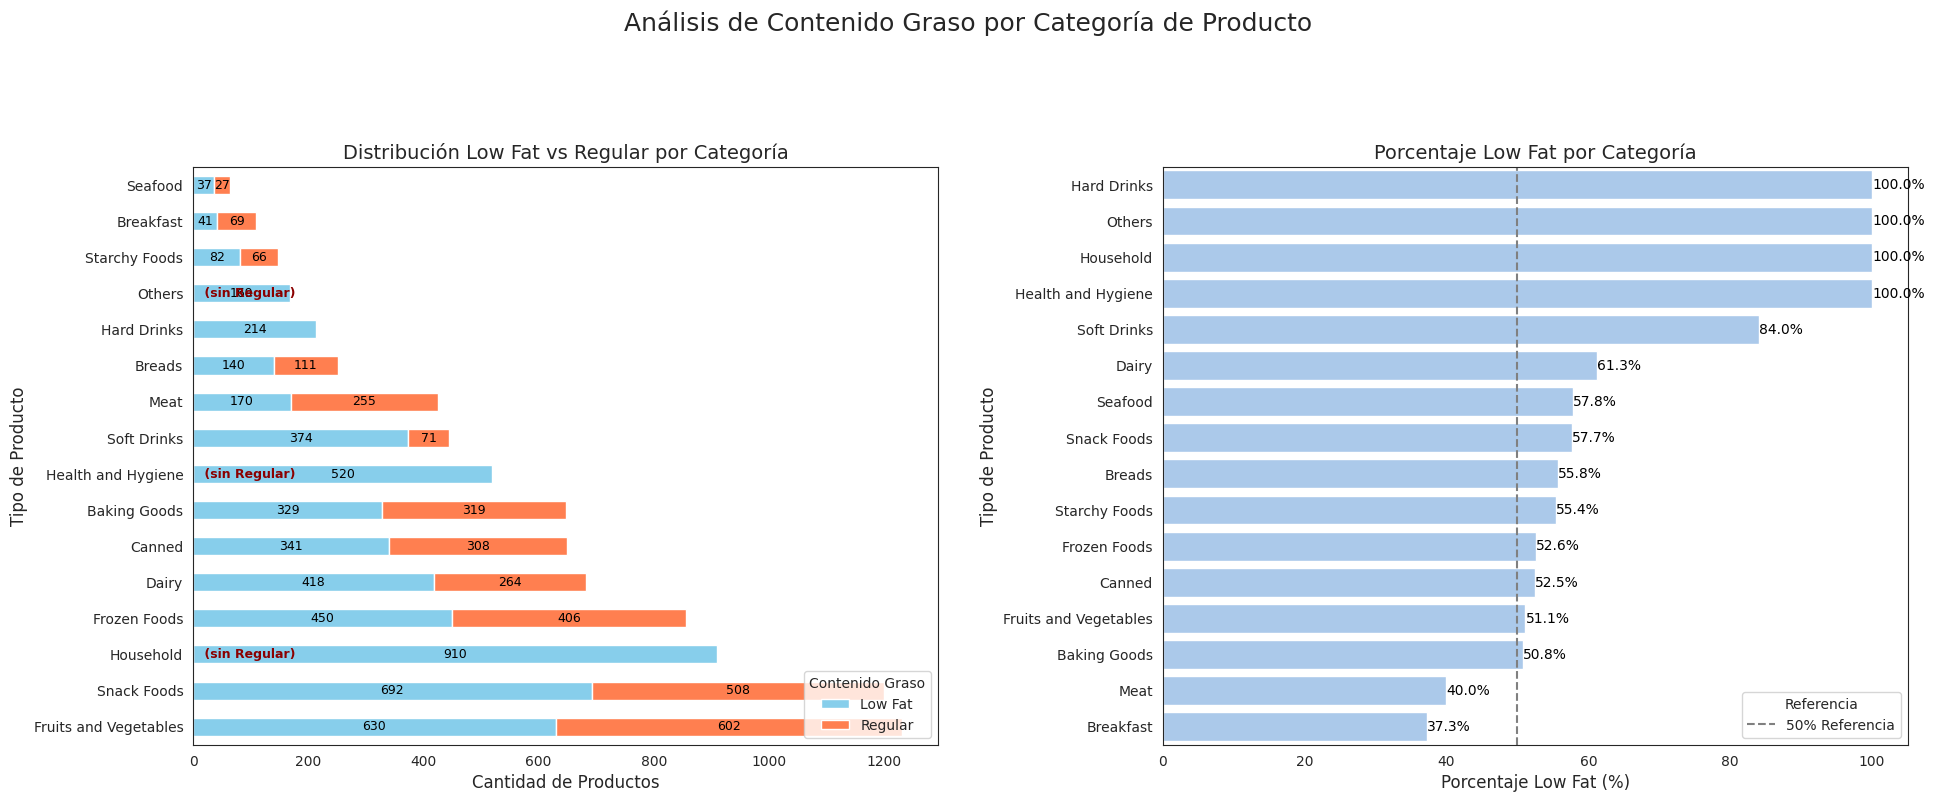


--- Conclusión ---
Categorías donde 'Item_Fat_Content' no tiene sentido como variable (productos no comestibles):
- Household
- Health and Hygiene
- Others

Recomendación: Para estas categorías, el atributo de contenido graso es irrelevante. Se recomienda considerarlo como un valor 'N/A' o 'No Aplica' en lugar de 'Low Fat' o 'Regular' para evitar clasificaciones engañosas. Esto mejoraría la precisión de cualquier análisis o modelo que utilice 'Item_Fat_Content' para productos comestibles.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' DataFrame is already loaded from previous cells

# --- Parte 1: Limpieza de Item_Fat_Content ---
print("Valores únicos y su frecuencia en 'Item_Fat_Content' original:")
print(df['Item_Fat_Content'].value_counts())
print("\n")

# Estandarizar valores inconsistentes
df['Fat_Content_Clean'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

print("Valores únicos y su frecuencia en 'Fat_Content_Clean' (columna limpia):")
print(df['Fat_Content_Clean'].value_counts())
print("\n")

# --- Parte 2: Visualizaciones ---
# Set plotting style
sns.set_style("white")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Análisis de Contenido Graso por Categoría de Producto', fontsize=18, y=1.03)

# --- Izquierda: Gráfico de barras horizontal apiladas ---
# Calculate counts of 'Low Fat' and 'Regular' for each Item_Type
fat_content_stacked_data = df.groupby('Item_Type')['Fat_Content_Clean'].value_counts().unstack(fill_value=0)

# Calculate total products per category for sorting
fat_content_stacked_data['Total'] = fat_content_stacked_data['Low Fat'] + fat_content_stacked_data['Regular']
fat_content_stacked_data = fat_content_stacked_data.sort_values(by='Total', ascending=False).drop(columns='Total')

# Define pastel colors for 'Low Fat' and 'Regular'
colors_stacked = ['skyblue', 'coral'] # Blue pastel for Low Fat, Orange pastel for Regular

fat_content_stacked_data.plot(kind='barh', stacked=True, color=colors_stacked, ax=axes[0])
axes[0].set_title('Distribución Low Fat vs Regular por Categoría', fontsize=14)
axes[0].set_xlabel('Cantidad de Productos', fontsize=12)
axes[0].set_ylabel('Tipo de Producto', fontsize=12)
axes[0].tick_params(axis='x', rotation=0) # No rotation needed for horizontal bars
axes[0].legend(title='Contenido Graso', loc='lower right')

# Add values inside segments, only if > 0
for container in axes[0].containers:
    for i, patch in enumerate(container.patches):
        width = patch.get_width()
        if width > 0: # Only show value if it's greater than 0
            axes[0].annotate(f'{int(width)}', (patch.get_x() + width / 2, patch.get_y() + patch.get_height() / 2),
                             ha='center', va='center', color='black', fontsize=9)

# Highlight 'Household', 'Health and Hygiene', 'Others' with an annotation
non_edible_highlight = ['Household', 'Health and Hygiene', 'Others']
for item_type in non_edible_highlight:
    if item_type in fat_content_stacked_data.index:
        y_pos = fat_content_stacked_data.index.get_loc(item_type)
        # Annotation to the right of the bar label
        axes[0].text(axes[0].get_xlim()[1] * 0.01, y_pos, " (sin Regular)", va='center', ha='left', color='darkred', fontsize=9, weight='bold')


# --- Derecha: Gráfico de barras horizontal (Porcentaje Low Fat por Categoría) ---
# Calculate percentage of 'Low Fat' products per Item_Type
total_per_item_type = df.groupby('Item_Type').size()
low_fat_per_item_type = df[df['Fat_Content_Clean'] == 'Low Fat'].groupby('Item_Type').size()

percentage_low_fat = (low_fat_per_item_type / total_per_item_type * 100).fillna(0).sort_values(ascending=False)

# Using 'color' instead of 'palette' to avoid FutureWarning, choosing a pastel color
sns.barplot(x=percentage_low_fat.values, y=percentage_low_fat.index, ax=axes[1], color=sns.color_palette('pastel')[0])
axes[1].set_title('Porcentaje Low Fat por Categoría', fontsize=14)
axes[1].set_xlabel('Porcentaje Low Fat (%)', fontsize=12)
axes[1].set_ylabel('Tipo de Producto', fontsize=12)

# Add values at the end of each bar
for index, value in enumerate(percentage_low_fat):
    axes[1].text(value, index, f'{value:.1f}%', color='black', ha="left", va="center", fontsize=10)

# Add a vertical reference line at 50%
axes[1].axvline(50, color='gray', linestyle='--', linewidth=1.5, label='50% Referencia')
axes[1].legend(title='Referencia', loc='lower right')

# Adjust x-axis limit to ensure labels are visible
axes[1].set_xlim(0, 100 + percentage_low_fat.max() * 0.05) # Add some padding

plt.tight_layout(pad=3)
plt.show()

# --- Parte 3: Conclusión ---
print("\n--- Conclusión ---")
non_edible_categories = [
    'Household', 'Health and Hygiene', 'Others',
    # Add other non-edible categories if identified in the Item_Type list
]

print("Categorías donde 'Item_Fat_Content' no tiene sentido como variable (productos no comestibles):")
for category in non_edible_categories:
    if category in df['Item_Type'].unique():
        print(f"- {category}")

print("\nRecomendación: Para estas categorías, el atributo de contenido graso es irrelevante. Se recomienda considerarlo como un valor 'N/A' o 'No Aplica' en lugar de 'Low Fat' o 'Regular' para evitar clasificaciones engañosas. Esto mejoraría la precisión de cualquier análisis o modelo que utilice 'Item_Fat_Content' para productos comestibles.")

6. ¿El tamaño importa? Análisis por tamaño de tienda

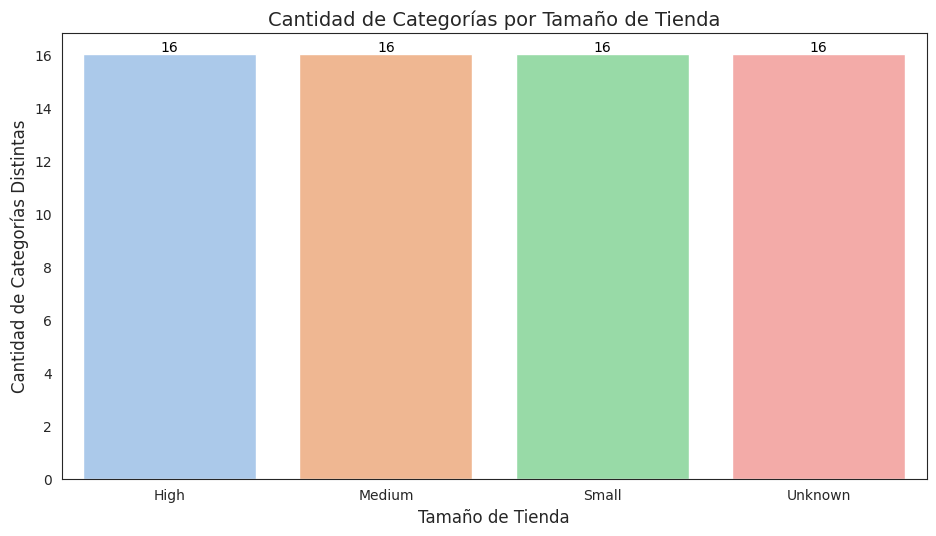


--- Conclusión ---

Todas las tiendas de tamaños conocidos ('High', 'Medium', 'Small') ofrecen la misma cantidad de categorías de productos (16). Por lo tanto, en este dataset, un tamaño de tienda 'más grande' no significa una mayor variedad, lo que sugiere que la variedad de productos está estandarizada y no representa 'demasiadas' opciones por tamaño de tienda.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Asegurarse de que el DataFrame 'df' esté cargado
# Si df no está cargado, descomentar y ejecutar la siguiente línea
# try:
#     df = pd.read_csv('/content/TP bigmart_data.csv')
# except FileNotFoundError:
#     print("Error: 'TP bigmart_data.csv' not found. Please ensure the file is uploaded correctly.")
#     exit()

# 1. Reemplazar valores nulos en 'Outlet_Size' por 'Unknown'
df['Outlet_Size'] = df['Outlet_Size'].fillna('Unknown')

# Set plotting style
sns.set_style("white") # Fondo blanco, estilo limpio

# 2. Preparar datos para el gráfico
# Cantidad de categorías Item_Type distintas que ofrece cada Outlet_Size
categories_per_size = df.groupby('Outlet_Size')['Item_Type'].nunique().sort_values(ascending=False)

# Create a pastel color palette with the exact number of colors needed
pastel_palette = sns.color_palette("pastel", n_colors=len(categories_per_size))

# Crear figura y un solo subplot
fig, ax = plt.subplots(figsize=(10, 6))

# --- Gráfico: Cantidad de Categorías por Tamaño de Tienda ---
sns.barplot(x=categories_per_size.index, y=categories_per_size.values, palette=pastel_palette, ax=ax, hue=categories_per_size.index, legend=False)
ax.set_title('Cantidad de Categorías por Tamaño de Tienda', fontsize=14)
ax.set_xlabel('Tamaño de Tienda', fontsize=12)
ax.set_ylabel('Cantidad de Categorías Distintas', fontsize=12)

# Valores encima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points',
                 fontsize=10, color='black')

plt.tight_layout(pad=3)
plt.show()

# 3. Conclusión
print('\n--- Conclusión ---\n')

# Analizar si las tiendas más grandes ofrecen más categorías
# Considerando 'High', 'Medium', 'Small' como representaciones de tamaño
# and assuming 'Unknown' will be treated as an anomaly or to be ignored for this specific conclusion about 'size'

# Get counts for known sizes
high_categories = categories_per_size.get('High', 0)
medium_categories = categories_per_size.get('Medium', 0)
small_categories = categories_per_size.get('Small', 0)

# Check if all known sizes have the same number of categories
if high_categories == medium_categories and medium_categories == small_categories and high_categories > 0:
    conclusion = f"Todas las tiendas de tamaños conocidos ('High', 'Medium', 'Small') ofrecen la misma cantidad de categorías de productos ({int(high_categories)}). Por lo tanto, en este dataset, un tamaño de tienda 'más grande' no significa una mayor variedad, lo que sugiere que la variedad de productos está estandarizada y no representa 'demasiadas' opciones por tamaño de tienda."
elif high_categories == categories_per_size.max() and high_categories > 0:
    conclusion = f"Las tiendas 'High' ofrecen la mayor cantidad de categorías de productos ({int(high_categories)}). Aunque esto podría indicar más opciones, la diversidad en sí misma no necesariamente es 'demasiada' sin un análisis de ventas y rentabilidad por categoría."
else:
    conclusion = f"No hay una relación directa donde las tiendas más grandes (según su clasificación) ofrezcan más categorías que las pequeñas. Por ejemplo, la tienda con más categorías es '{categories_per_size.index[0]}' con {int(categories_per_size.iloc[0])} categorías. Esto sugiere que la cantidad de opciones no está ligada directamente al tamaño nominal de la tienda."

print(conclusion)

7. ¿La ubicación importa? Análisis por tipo de ubicación geográfica (Tier 1, 2, 3)


--- Top 50 Productos - Tier 1 ---


,Item_Identifier,Item_Type,Ventas_Totales
1252,NCM05,Health and Hygiene,"$14,273.42"
626,FDO11,Breads,"$13,695.51"
320,FDF04,Frozen Foods,"$12,916.52"
259,FDD17,Frozen Foods,"$12,835.29"
1358,NCU54,Household,"$12,583.62"
1319,NCQ53,Health and Hygiene,"$12,054.31"
1402,NCZ54,Household,"$12,021.68"
1092,FDY56,Fruits and Vegetables,"$11,736.72"
1397,NCZ18,Household,"$11,415.14"
332,FDF22,Snack Foods,"$11,327.26"



--- Top 50 Productos - Tier 2 ---


,Item_Identifier,Item_Type,Ventas_Totales
145,FDA15,Dairy,"$18,426.68"
870,FDT21,Snack Foods,"$17,928.66"
390,FDG45,Fruits and Vegetables,"$17,628.39"
181,FDB11,Starchy Foods,"$15,752.83"
806,FDR59,Breads,"$15,699.56"
91,DRJ51,Dairy,"$14,973.84"
640,FDN51,Meat,"$14,876.64"
1146,FDZ20,Fruits and Vegetables,"$14,751.46"
332,FDF05,Frozen Foods,"$14,727.50"
379,FDG26,Canned,"$14,610.98"



--- Top 50 Productos - Tier 3 ---


,Item_Identifier,Item_Type,Ventas_Totales
147,FDA15,Dairy,"$19,422.72"
539,FDK40,Frozen Foods,"$18,935.35"
1260,NCE42,Household,"$18,929.36"
1181,FDZ20,Fruits and Vegetables,"$18,820.83"
1161,FDY55,Fruits and Vegetables,"$18,246.91"
1246,NCD18,Household,"$17,968.61"
477,FDI50,Canned,"$17,177.64"
1285,NCH18,Household,"$16,951.93"
1081,FDX13,Canned,"$16,932.63"
1475,NCX30,Household,"$16,842.08"


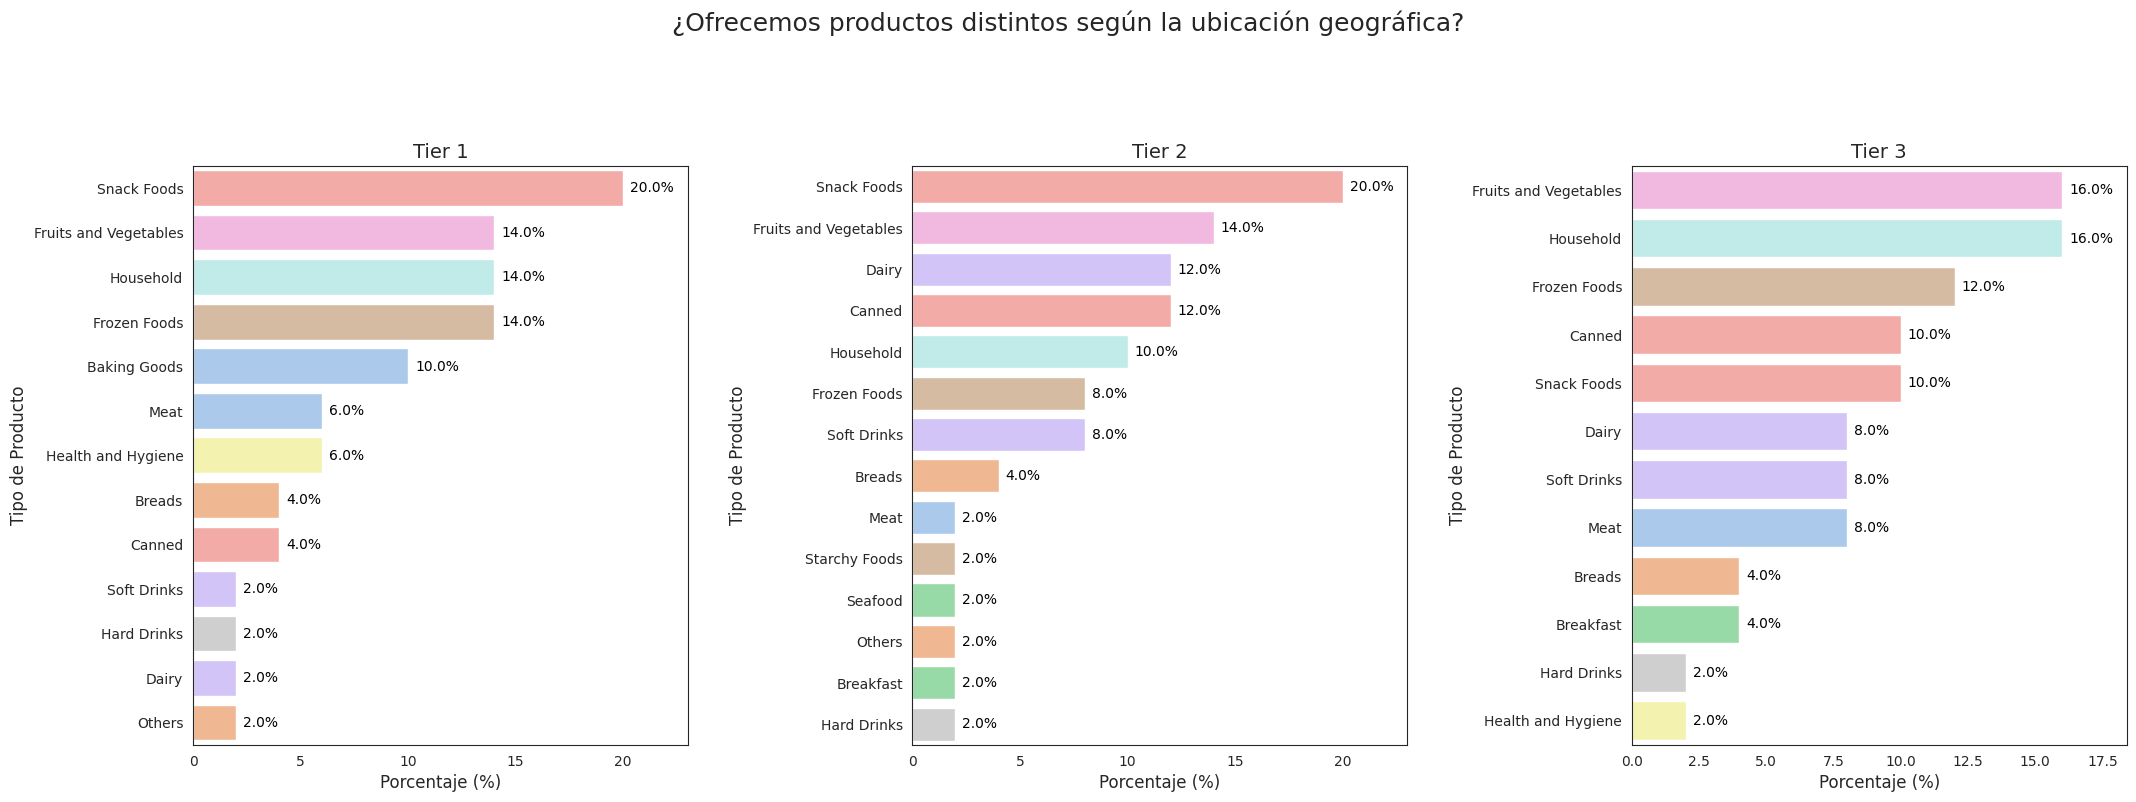


--- Conclusiones ---

CONCLUSIÓN 1 — Existen diferencias en el portafolio de productos más vendidos entre los tiers. Aunque categorías como 'Fruits and Vegetables' son comunes entre las Top 3, no hay una consistencia total en las categorías dominantes en todos los tiers.
CONCLUSIÓN 2 — La categoría que consistentemente domina en los Top 50 productos de todos los tiers es 'Fruits and Vegetables' (con un promedio del 14.7%).
CONCLUSIÓN 3 — Sí, se observan categorías que aparecen fuertemente (en el Top 3) en un tier específico pero no en otros. Por ejemplo: 'Frozen Foods' (prominente en Tier 3 con 12.0%) -- Top 3 en Tier 3, no Top 3 en otros Tiers; 'Dairy' (prominente en Tier 2 con 12.0%) -- Top 3 en Tier 2, no Top 3 en otros Tiers. Esto sugiere adaptaciones del surtido a las particularidades del mercado local.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display, HTML

# Ensure df is loaded. Assuming it's already available from previous cells.
# If not, uncomment and run:
# try:
#     df = pd.read_csv('/content/TP bigmart_data.csv')
# except FileNotFoundError:
#     print("Error: 'TP bigmart_data.csv' not found. Please ensure the file is uploaded correctly.")
#     exit()

# 1. Prepare data for each Tier and display Top 50 Products
tier_data = {}
# Use a specific order for location types to ensure consistent plotting order
location_types_ordered = ['Tier 1', 'Tier 2', 'Tier 3']

for tier in location_types_ordered:
    # Filter the DataFrame for the current Tier
    df_tier = df[df['Outlet_Location_Type'] == tier]

    # Calculate total sales by Item_Identifier and Item_Type for this Tier
    # Group by both to keep Item_Type associated with Item_Identifier
    sales_by_item = df_tier.groupby(['Item_Identifier', 'Item_Type'])['Item_Outlet_Sales'].sum().reset_index()

    # Get the Top 50 products of this Tier
    top_50_products = sales_by_item.sort_values(by='Item_Outlet_Sales', ascending=False).head(50)

    # Display Top 50 Products table
    print(f"\n--- Top 50 Productos - {tier} ---")
    # Create a copy to avoid SettingWithCopyWarning when formatting
    display_df = top_50_products.copy()
    display_df.rename(columns={'Item_Outlet_Sales': 'Ventas_Totales'}, inplace=True)
    display_df['Ventas_Totales'] = display_df['Ventas_Totales'].apply(lambda x: f'${x:,.2f}')
    display(display_df[['Item_Identifier', 'Item_Type', 'Ventas_Totales']])

    # Count how many of those 50 products belong to each category (Item_Type)
    item_type_counts = top_50_products['Item_Type'].value_counts()

    # Calculate the percentage of representation
    total_top_products = item_type_counts.sum() # This will be 50 unless there are fewer than 50 unique items
    item_type_percentages = (item_type_counts / total_top_products * 100).sort_values(ascending=False)

    tier_data[tier] = item_type_percentages

# 2. Visualization
sns.set_style("white") # Clean style, white background

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('¿Ofrecemos productos distintos según la ubicación geográfica?', fontsize=18, y=1.03)

# Define a pastel color palette. The number of colors should be at least the max number of item types
# in any tier's top 50, or just a sufficiently large number.
all_unique_item_types_in_top50 = set()
for tier_perc_series in tier_data.values():
    all_unique_item_types_in_top50.update(tier_perc_series.index)
num_colors = len(all_unique_item_types_in_top50)
pastel_palette = sns.color_palette("pastel", n_colors=num_colors)

# Map Item_Type to a consistent color for all plots
color_map = {item_type: pastel_palette[i % num_colors] for i, item_type in enumerate(sorted(list(all_unique_item_types_in_top50)))}


# Iterate through tiers and create horizontal bar charts
for i, tier in enumerate(location_types_ordered):
    data_to_plot = tier_data[tier]
    ax = axes[i]

    if not data_to_plot.empty:
        # Create a list of colors for the current tier's bars based on the color_map
        bar_colors = [color_map[item_type] for item_type in data_to_plot.index]
        # Modified: explicitly assign y variable to hue as suggested by FutureWarning
        sns.barplot(x=data_to_plot.values, y=data_to_plot.index, ax=ax, palette=bar_colors, orient='h', hue=data_to_plot.index, legend=False)
    else:
        # Handle empty data case
        ax.text(0.5, 0.5, 'No hay datos de Top 50', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_yticks([]) # Hide y-axis ticks for empty plot

    ax.set_title(f'{tier}', fontsize=14)
    ax.set_xlabel('Porcentaje (%)', fontsize=12)
    ax.set_ylabel('Tipo de Producto', fontsize=12)

    # Valores al final de cada barra con %
    for p in ax.patches:
        width = p.get_width()
        # Only annotate if width > 0 to avoid clutter for tiny bars
        if width > 0:
            ax.annotate(f'{width:.1f}%', (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                        fontsize=10, color='black')

    # Adjust x-axis limits to give space to labels
    if not data_to_plot.empty:
        ax.set_xlim(0, data_to_plot.max() * 1.15) # Add 15% padding
    else:
        ax.set_xlim(0, 100) # Default for empty data

plt.tight_layout(pad=3)
plt.show()

# 3. Conclusiones
print('\n--- Conclusiones ---\n')

# Get top N categories for each tier for comparison in conclusions
top_n_for_conclusions = 3
tier1_top_categories_set = set(tier_data['Tier 1'].head(top_n_for_conclusions).index)
tier2_top_categories_set = set(tier_data['Tier 2'].head(top_n_for_conclusions).index)
tier3_top_categories_set = set(tier_data['Tier 3'].head(top_n_for_conclusions).index)

# Conclusion 1: ¿Los tres tiers tienen el mismo portafolio o hay diferencias?
if tier1_top_categories_set == tier2_top_categories_set and tier2_top_categories_set == tier3_top_categories_set:
    common_top_categories_list = list(tier1_top_categories_set)
    conclusion1 = f"CONCLUSIÓN 1 — El portafolio de productos más vendidos es muy similar en su composición de categorías principales en todos los tiers. Las {top_n_for_conclusions} categorías más destacadas son consistentes en Tier 1, Tier 2 y Tier 3, incluyendo '{', '.join(common_top_categories_list)}'."
else:
    all_top_categories_union = tier1_top_categories_set.union(tier2_top_categories_set).union(tier3_top_categories_set)
    intersection_all = tier1_top_categories_set.intersection(tier2_top_categories_set).intersection(tier3_top_categories_set)

    if intersection_all:
        conclusion1 = f"CONCLUSIÓN 1 — Existen diferencias en el portafolio de productos más vendidos entre los tiers. Aunque categorías como '{', '.join(list(intersection_all))}' son comunes entre las Top {top_n_for_conclusions}, no hay una consistencia total en las categorías dominantes en todos los tiers."
    else:
        conclusion1 = f"CONCLUSIÓN 1 — Hay diferencias significativas en el portafolio de productos más vendidos entre los tiers. Las Top {top_n_for_conclusions} categorías son distintas en cada ubicación, sugiriendo preferencias de mercado regionales marcadas."

print(conclusion1)

# Conclusion 2: ¿Qué categorías dominan en todos los tiers?
common_dominant_categories = list(tier1_top_categories_set.intersection(tier2_top_categories_set).intersection(tier3_top_categories_set))

if common_dominant_categories:
    avg_percentages = {}
    for cat in common_dominant_categories:
        p1 = tier_data['Tier 1'].get(cat, 0)
        p2 = tier_data['Tier 2'].get(cat, 0)
        p3 = tier_data['Tier 3'].get(cat, 0)
        avg_percentages[cat] = (p1 + p2 + p3) / 3

    sorted_avg_percentages = sorted(avg_percentages.items(), key=lambda item: item[1], reverse=True)

    if len(sorted_avg_percentages) > 1:
        top1_cat, top1_pct = sorted_avg_percentages[0]
        top2_cat, top2_pct = sorted_avg_percentages[1]
        conclusion2 = f"CONCLUSIÓN 2 — Las categorías que consistentemente dominan en los Top 50 productos de todos los tiers son '{top1_cat}' (con un promedio del {top1_pct:.1f}%) y '{top2_cat}' (con un promedio del {top2_pct:.1f}%). Estas representan pilares de ventas en todas las ubicaciones geográficas."
    else:
        top1_cat, top1_pct = sorted_avg_percentages[0]
        conclusion2 = f"CONCLUSIÓN 2 — La categoría que consistentemente domina en los Top 50 productos de todos los tiers es '{top1_cat}' (con un promedio del {top1_pct:.1f}%)."
else:
    conclusion2 = "CONCLUSIÓN 2 — No se identificaron categorías que dominen consistentemente en las Top 3 de los Top 50 productos de todos los tiers."

print(conclusion2)

# Conclusion 3: ¿Hay alguna categoría que aparezca fuerte en un tier pero no en otro?
unique_strong_categories = []

for cat in all_top_categories_union:
    is_top_in_tier1 = cat in tier1_top_categories_set
    is_top_in_tier2 = cat in tier2_top_categories_set
    is_top_in_tier3 = cat in tier3_top_categories_set

    count_top_appearances = is_top_in_tier1 + is_top_in_tier2 + is_top_in_tier3

    if count_top_appearances == 1: # Appears in the top N of exactly one tier
        if is_top_in_tier1:
            unique_strong_categories.append(f"'{cat}' (prominente en Tier 1 con {tier_data['Tier 1'].get(cat, 0):.1f}%) -- Top 3 en Tier 1, no Top 3 en otros Tiers")
        elif is_top_in_tier2:
            unique_strong_categories.append(f"'{cat}' (prominente en Tier 2 con {tier_data['Tier 2'].get(cat, 0):.1f}%) -- Top 3 en Tier 2, no Top 3 en otros Tiers")
        elif is_top_in_tier3:
            unique_strong_categories.append(f"'{cat}' (prominente en Tier 3 con {tier_data['Tier 3'].get(cat, 0):.1f}%) -- Top 3 en Tier 3, no Top 3 en otros Tiers")

if unique_strong_categories:
    conclusion3 = "CONCLUSIÓN 3 — Sí, se observan categorías que aparecen fuertemente (en el Top 3) en un tier específico pero no en otros. Por ejemplo: " + "; ".join(unique_strong_categories) + ". Esto sugiere adaptaciones del surtido a las particularidades del mercado local."
else:
    conclusion3 = "CONCLUSIÓN 3 — No se identificaron categorías que destaquen exclusivamente en el Top 3 de un solo tier, indicando una distribución relativamente homogénea de las categorías de mayor impacto."

print(conclusion3)


In [ ]:
print("--- CONCLUSIONES DEL ANÁLISIS ---\n")
print("**Portafolio de Productos:** El análisis reveló que categorías como 'Fruits and Vegetables' y 'Snack Foods' dominan en volumen de productos, mientras que 'Fruits and Vegetables' y 'Household' lideran en ventas totales, lo que indica un enfoque en productos esenciales. Notablemente, todas las tiendas, independientemente de su tamaño, ofrecen las mismas 16 categorías de productos, sugiriendo una estandarización sin diferenciación local significativa.\n")
print("**Rendimiento por Tipo de Tienda:** 'Supermarket Type 1' es el líder en ventas totales, generando aproximadamente $12.9M con 6 tiendas. Sin embargo, 'Supermarket Type 3' destaca por su eficiencia, alcanzando $3.4M con una sola tienda. En contraste, los 'Grocery Store' son los de menor rendimiento, promediando solo $184K por tienda, lo que señala la necesidad de una reevaluación de su modelo.\n")
print("**Rendimiento por Ubicación Geográfica:** 'Tier 3' lidera en ventas totales con $7.6M, mientras que 'Tier 2' se posiciona como el más eficiente, generando $6.4M con solo 3 tiendas, lo que subraya su alto potencial. La combinación de 'Supermarket Type 1' en 'Tier 2' emerge como la más potente, indicando sinergias exitosas entre tipo de tienda y ubicación.\n")

print("--- RECOMENDACIONES ESTRATÉGICAS ---\n")
print("1. **Rediseñar el Portafolio por Tienda para Maximizar Ventas**\n")
print("   **Por qué:** A pesar de que todas las tiendas ofrecen 16 categorías idénticas, el análisis de los Top 50 productos por 'Tier' (ej., 'Frozen Foods' en Tier 3 y 'Dairy' en Tier 2) muestra preferencias locales claras que no están siendo totalmente explotadas.\n")
print("   **Para qué:** Adaptar la oferta de productos a la demanda específica de cada ubicación (tier y tipo de tienda) permitirá capitalizar los nichos de mercado, mejorar la relevancia del inventario y, en última instancia, incrementar las ventas y la rentabilidad al reducir el stock no deseado y potenciar los productos con mayor tracción local.\n")

print("2. **Optimizar Operaciones Logísticas y Modelo de Negocio**\n")
print("   **Por qué:** Los 'Grocery Store' tienen un rendimiento promedio muy bajo ($184K por tienda), mientras que 'Supermarket Type 3' demuestra una eficiencia excepcional ($3.4M con una sola tienda). Esta disparidad sugiere ineficiencias en la cadena de suministro o en el modelo operativo de las tiendas con bajo rendimiento.\n")
print("   **Para qué:** Analizar y replicar las mejores prácticas de 'Supermarket Type 3' en otros formatos, especialmente en los 'Grocery Store', para mejorar la eficiencia operativa, reducir costos, optimizar la gestión de inventario y, potencialmente, transformar formatos menos rentables en activos más productivos.\n")

print("3. **Focalizar Estrategias de Marketing en Segmentos de Alto Rendimiento**\n")
print("   **Por qué:** La combinación 'Supermarket Type 1' en 'Tier 2' ha sido identificada como la más poderosa, con 'Tier 2' generando $6.4M en 3 tiendas, lo que indica una concentración de valor en segmentos específicos del mercado.\n")
print("   **Para qué:** Dirigir y personalizar las campañas de marketing hacia estos segmentos de alto rendimiento permitirá maximizar el retorno de la inversión (ROI). Esto incluye promociones específicas para las categorías de productos fuertes en cada 'Tier' (e.g., 'Frozen Foods' en Tier 3, 'Dairy' en Tier 2) y campañas que resalten la propuesta de valor de los formatos exitosos en las ubicaciones más eficientes.\n")

print("4. **Implementar Modelos Predictivos para la Gestión de la Demanda**\n")
print("   **Por qué:** La estandarización de las 16 categorías de productos en todas las tiendas, junto con las diferencias de rendimiento por ubicación y tipo de tienda, sugiere que la asignación de inventario actual puede no estar alineada con la demanda real. Las recomendaciones anteriores (rediseño de portafolio y optimización logística) se beneficiarían enormemente de una comprensión predictiva.\n")
print("   **Para qué:** Desarrollar e implementar modelos predictivos avanzados permitirá a BigMart anticipar con mayor precisión la demanda de productos por categoría, tienda y ubicación. Esto conducirá a una gestión de inventario más inteligente, minimizando el exceso de stock y las roturas de stock, optimizando la cadena de suministro y asegurando que los productos correctos estén disponibles en el lugar y momento adecuados.\n")

--- CONCLUSIONES DEL ANÁLISIS ---

**Portafolio de Productos:** El análisis reveló que categorías como 'Fruits and Vegetables' y 'Snack Foods' dominan en volumen de productos, mientras que 'Fruits and Vegetables' y 'Household' lideran en ventas totales, lo que indica un enfoque en productos esenciales. Notablemente, todas las tiendas, independientemente de su tamaño, ofrecen las mismas 16 categorías de productos, sugiriendo una estandarización sin diferenciación local significativa.

**Rendimiento por Tipo de Tienda:** 'Supermarket Type 1' es el líder en ventas totales, generando aproximadamente $12.9M con 6 tiendas. Sin embargo, 'Supermarket Type 3' destaca por su eficiencia, alcanzando $3.4M con una sola tienda. En contraste, los 'Grocery Store' son los de menor rendimiento, promediando solo $184K por tienda, lo que señala la necesidad de una reevaluación de su modelo.

**Rendimiento por Ubicación Geográfica:** 'Tier 3' lidera en ventas totales con $7.6M, mientras que 'Tier 2' se pos